Acesse:
https://pandas.pydata.org/docs/user_guide/index.html

Acesse: https://pandas.pydata.org/docs/user_guide/index.html

Dados em csv:
https://www.kaggle.com/drgilermo/nba-players-stats


## 8.1 - Estrutura de dados no Pandas


*Series* - *Series* são estruturas de dados 1D e podem ser criadas a partir de dicionários, arrays, entre outros. É muito parecido com os arrays em termos de propriedades e métodos.
- pd.Series(data, index=index)

*DataFrame* - *DataFrames* são estruturas de dados 2D e podem ser criadas a partir de dicionários, dados estruturados em 2D, arquivos csv, etc. Em resumo, DataFrame é uma **tabela**.
- pd.DataFrame({'key_1': pd.Series(...), 'key_n':pd.Series(...)})
- pd.read_csv(file)



In [1]:
# Dados

lista_a = [11,22,33,44,55]
lista_b = ['a','b','c','d','e']

import numpy as np

arr = np.arange(10)**2

dic = {'a':123,'b':456,'c':789}

dic2 = {'coluna1':np.arange(10)*5,'coluna2':np.arange(10)**2,'coluna3':np.ones(10)}
dic2['coluna1']

array([ 0,  5, 10, 15, 20, 25, 30, 35, 40, 45])

In [7]:
import pandas as pd

serie_1 = pd.Series(lista_b,index=lista_a)
serie_1[22]

'b'

In [6]:
serie_3 = pd.Series(arr)
serie_3

0     0
1     1
2     4
3     9
4    16
5    25
6    36
7    49
8    64
9    81
dtype: int32

In [10]:
serie_4 = pd.Series(dic)
serie_4['b']

456

In [14]:
df1 = pd.DataFrame(dic2)
type(df1['coluna1'])

pandas.core.series.Series

In [15]:
arr2 = np.arange(15).reshape(5,3)


df3 = pd.DataFrame(arr2)

df3

,0,1,2
0,0,1,2
1,3,4,5
2,6,7,8
3,9,10,11
4,12,13,14


In [16]:
file = 'C:/Users/gabriel.pereira/OneDrive - Grupo ITG/Área de Trabalho/Cursos/Python Basico avanç Udemy/Python-para-Engenheiros-e-Cientistas-main/Notebooks/arquivos_auxiliares/datasets_1358_30676_Players.csv'

NBA_players = pd.read_csv(file)
NBA_players

,Unnamed: 0,Player,height,weight,collage,born,birth_city,birth_state
0,0,Curly Armstrong,180.0,77.0,Indiana University,1918.0,NaN,NaN
1,1,Cliff Barker,188.0,83.0,University of Kentucky,1921.0,Yorktown,Indiana
2,2,Leo Barnhorst,193.0,86.0,University of Notre Dame,1924.0,NaN,NaN
3,3,Ed Bartels,196.0,88.0,North Carolina State University,1925.0,NaN,NaN
4,4,Ralph Beard,178.0,79.0,University of Kentucky,1927.0,Hardinsburg,Kentucky
...,...,...,...,...,...,...,...,...
3917,3917,Troy Williams,198.0,97.0,South Carolina State University,1969.0,Columbia,South Carolina
3918,3918,Kyle Wiltjer,208.0,108.0,Gonzaga University,1992.0,Portland,Oregon
3919,3919,Stephen Zimmerman,213.0,108.0,"University of Nevada, Las Vegas",1996.0,Hendersonville,Tennessee
3920,3920,Paul Zipser,203.0,97.0,NaN,1994.0,Heidelberg,Germany


## 8.2 Funcionalidades básicas

Acesse: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html


#### Algumas propriedades de DataFrames

shape, size, dtypes, columns, index (retorna linhas), values (retorna array)


#### Alguns métodos para DataFrames


| Métodos aplicados ao DataFrame | Descrição |
| :-- | :-- |
| .head(*optativo*) | para ver primeiras linhas |
| .tail(*optativo*) | para ver últimas linhas |
| .to_csv(*path/name*) |  exporta o DF para um arquivo csv (esse método existe para vários outros formatos) |
| .min(axis), .max(axis), .cumsum(),mean() | similar as discutidas na seção de Numpy |
| .value_counts() | Este método faz uma contagem de aparições de determinado valor (aplicar para Series) |
| .sort_values(by=column) | Ordena valores. |


In [17]:
import pandas as pd


lista_a = ['a','a','b','c','a','d','c']

lista_b = list(range(7))

dic = {'string':lista_a,'numeros':lista_b}
dic

{'string': ['a', 'a', 'b', 'c', 'a', 'd', 'c'],
 'numeros': [0, 1, 2, 3, 4, 5, 6]}

In [19]:
df = pd.DataFrame(dic)
df

,string,numeros
0,a,0
1,a,1
2,b,2
3,c,3
4,a,4
5,d,5
6,c,6


In [21]:
df.shape

(7, 2)

In [22]:
df.size

14

In [23]:
df.dtypes

string     object
numeros     int64
dtype: object

In [24]:
df.columns

Index(['string', 'numeros'], dtype='object')

In [25]:
df.index

RangeIndex(start=0, stop=7, step=1)

In [26]:
df.values

array([['a', 0],
       ['a', 1],
       ['b', 2],
       ['c', 3],
       ['a', 4],
       ['d', 5],
       ['c', 6]], dtype=object)

In [29]:
import numpy as np

df2 = pd.DataFrame({'col1':np.arange(100)**2,'col2':np.arange(100)*5})
df2.head()

,col1,col2
0,0,0
1,1,5
2,4,10
3,9,15
4,16,20


In [30]:
df.cumsum()

,string,numeros
0,a,0
1,aa,1
2,aab,3
3,aabc,6
4,aabca,10
5,aabcad,15
6,aabcadc,21


In [31]:
df['string'].value_counts()

a    3
c    2
b    1
d    1
Name: string, dtype: int64

In [32]:
df.sort_values(by='string')

,string,numeros
0,a,0
1,a,1
4,a,4
2,b,2
3,c,3
6,c,6
5,d,5


## 8.3 Tratando dados (Exemplo prático 1)

A partir dos dados de jogadores da NBA (https://www.kaggle.com/drgilermo/nba-players-stats), pede-se:

- Qual a média de altura e de peso dos jogadores?
- Crie uma nova coluna com a razão peso/altura.
- Qual a maior altura, o maior peso, a menor altura e menor peso?
- Qual é o estado onde nasce o maior número de jogadores?
- Qual o jogador mais alto?

In [38]:
import pandas as pd

file = 'C:/Users/gabriel.pereira/OneDrive - Grupo ITG/Área de Trabalho/Cursos/Python Basico avanç Udemy/Python-para-Engenheiros-e-Cientistas-main/Notebooks/arquivos_auxiliares/datasets_1358_30676_Players.csv'

df = pd.read_csv(file)
df

,Unnamed: 0,Player,height,weight,collage,born,birth_city,birth_state
0,0,Curly Armstrong,180.0,77.0,Indiana University,1918.0,NaN,NaN
1,1,Cliff Barker,188.0,83.0,University of Kentucky,1921.0,Yorktown,Indiana
2,2,Leo Barnhorst,193.0,86.0,University of Notre Dame,1924.0,NaN,NaN
3,3,Ed Bartels,196.0,88.0,North Carolina State University,1925.0,NaN,NaN
4,4,Ralph Beard,178.0,79.0,University of Kentucky,1927.0,Hardinsburg,Kentucky
...,...,...,...,...,...,...,...,...
3917,3917,Troy Williams,198.0,97.0,South Carolina State University,1969.0,Columbia,South Carolina
3918,3918,Kyle Wiltjer,208.0,108.0,Gonzaga University,1992.0,Portland,Oregon
3919,3919,Stephen Zimmerman,213.0,108.0,"University of Nevada, Las Vegas",1996.0,Hendersonville,Tennessee
3920,3920,Paul Zipser,203.0,97.0,NaN,1994.0,Heidelberg,Germany


In [40]:
df['height'].mean()

198.70492221372098

In [41]:
df['weight'].mean()

94.78321856669217

In [45]:
df['razão'] = df['weight']/df['height']
df

,Unnamed: 0,Player,height,weight,collage,born,birth_city,birth_state,razão
0,0,Curly Armstrong,180.0,77.0,Indiana University,1918.0,NaN,NaN,0.427778
1,1,Cliff Barker,188.0,83.0,University of Kentucky,1921.0,Yorktown,Indiana,0.441489
2,2,Leo Barnhorst,193.0,86.0,University of Notre Dame,1924.0,NaN,NaN,0.445596
3,3,Ed Bartels,196.0,88.0,North Carolina State University,1925.0,NaN,NaN,0.448980
4,4,Ralph Beard,178.0,79.0,University of Kentucky,1927.0,Hardinsburg,Kentucky,0.443820
...,...,...,...,...,...,...,...,...,...
3917,3917,Troy Williams,198.0,97.0,South Carolina State University,1969.0,Columbia,South Carolina,0.489899
3918,3918,Kyle Wiltjer,208.0,108.0,Gonzaga University,1992.0,Portland,Oregon,0.519231
3919,3919,Stephen Zimmerman,213.0,108.0,"University of Nevada, Las Vegas",1996.0,Hendersonville,Tennessee,0.507042
3920,3920,Paul Zipser,203.0,97.0,NaN,1994.0,Heidelberg,Germany,0.477833


In [62]:
df['IMC'] = df['weight']/((df['height']/100)**2)
df

,Unnamed: 0,Player,height,weight,collage,born,birth_city,birth_state,razão,IMC
0,0,Curly Armstrong,180.0,77.0,Indiana University,1918.0,NaN,NaN,0.427778,23.765432
1,1,Cliff Barker,188.0,83.0,University of Kentucky,1921.0,Yorktown,Indiana,0.441489,23.483477
2,2,Leo Barnhorst,193.0,86.0,University of Notre Dame,1924.0,NaN,NaN,0.445596,23.087868
3,3,Ed Bartels,196.0,88.0,North Carolina State University,1925.0,NaN,NaN,0.448980,22.907122
4,4,Ralph Beard,178.0,79.0,University of Kentucky,1927.0,Hardinsburg,Kentucky,0.443820,24.933720
...,...,...,...,...,...,...,...,...,...,...
3917,3917,Troy Williams,198.0,97.0,South Carolina State University,1969.0,Columbia,South Carolina,0.489899,24.742373
3918,3918,Kyle Wiltjer,208.0,108.0,Gonzaga University,1992.0,Portland,Oregon,0.519231,24.963018
3919,3919,Stephen Zimmerman,213.0,108.0,"University of Nevada, Las Vegas",1996.0,Hendersonville,Tennessee,0.507042,23.804801
3920,3920,Paul Zipser,203.0,97.0,NaN,1994.0,Heidelberg,Germany,0.477833,23.538547


In [46]:
df['height'].max()

231.0

In [47]:
df['weight'].max()

163.0

In [48]:
df['weight'].min()

60.0

In [56]:
df['birth_state'].value_counts().idxmax()

'California'

In [63]:
df['birth_state'].value_counts()

California                          344
New York                            290
Illinois                            209
Pennsylvania                        163
Ohio                                137
                                   ... 
Saint Vincent and the Grenadines      1
Finland                               1
Dominica                              1
Norway                                1
Austria                               1
Name: birth_state, Length: 128, dtype: int64

In [67]:
df.loc[df['height'].idxmax(), 'Player']

'Manute Bol'

In [68]:
df.sort_values(by = 'height').tail(5)

,Unnamed: 0,Player,height,weight,collage,born,birth_city,birth_state,razão,IMC
2249,2249,P.J. Brown,229.0,106.0,NaN,1972.0,NaN,NaN,0.462882,20.213192
2248,2248,Shawn Bradley,229.0,106.0,Brigham Young University,1972.0,Landstuhl,Germany,0.462882,20.213192
1711,1711,Manute Bol,231.0,90.0,University of Bridgeport,1962.0,Gogrial,South Sudan,0.389610,16.866251
2297,2297,Gheorghe Muresan,231.0,137.0,NaN,1971.0,Triteni,Romania,0.593074,25.674182
223,223,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 8.4 Fatiando DataFrames com loc e iloc
Acesse: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html


- loc[i,j], onde i e j são os nomes dos índices
- iloc[i,j], onde i e j são os números dos índices


In [69]:
import pandas as pd

file = 'C:/Users/gabriel.pereira/OneDrive - Grupo ITG/Área de Trabalho/Cursos/Python Basico avanç Udemy/Python-para-Engenheiros-e-Cientistas-main/Notebooks/arquivos_auxiliares/datasets_1358_30676_Players.csv'

df = pd.read_csv(file)
df

,Unnamed: 0,Player,height,weight,collage,born,birth_city,birth_state
0,0,Curly Armstrong,180.0,77.0,Indiana University,1918.0,NaN,NaN
1,1,Cliff Barker,188.0,83.0,University of Kentucky,1921.0,Yorktown,Indiana
2,2,Leo Barnhorst,193.0,86.0,University of Notre Dame,1924.0,NaN,NaN
3,3,Ed Bartels,196.0,88.0,North Carolina State University,1925.0,NaN,NaN
4,4,Ralph Beard,178.0,79.0,University of Kentucky,1927.0,Hardinsburg,Kentucky
...,...,...,...,...,...,...,...,...
3917,3917,Troy Williams,198.0,97.0,South Carolina State University,1969.0,Columbia,South Carolina
3918,3918,Kyle Wiltjer,208.0,108.0,Gonzaga University,1992.0,Portland,Oregon
3919,3919,Stephen Zimmerman,213.0,108.0,"University of Nevada, Las Vegas",1996.0,Hendersonville,Tennessee
3920,3920,Paul Zipser,203.0,97.0,NaN,1994.0,Heidelberg,Germany


In [70]:
df.columns

Index(['Unnamed: 0', 'Player', 'height', 'weight', 'collage', 'born',
       'birth_city', 'birth_state'],
      dtype='object')

In [71]:
df.loc[1:4,['height','birth_state']]

,height,birth_state
1,188.0,Indiana
2,193.0,NaN
3,196.0,NaN
4,178.0,Kentucky


In [72]:
df.loc[1:4,'height':'birth_state']

,height,weight,collage,born,birth_city,birth_state
1,188.0,83.0,University of Kentucky,1921.0,Yorktown,Indiana
2,193.0,86.0,University of Notre Dame,1924.0,NaN,NaN
3,196.0,88.0,North Carolina State University,1925.0,NaN,NaN
4,178.0,79.0,University of Kentucky,1927.0,Hardinsburg,Kentucky


In [73]:
df.iloc[0:50:3,2:5]

,height,weight,collage
0,180.0,77.0,Indiana University
3,196.0,88.0,North Carolina State University
6,196.0,90.0,University of Kansas
9,196.0,95.0,University of Denver
12,190.0,79.0,Oklahoma State University
15,185.0,81.0,Louisiana State University
18,208.0,106.0,NaN
21,190.0,79.0,Seton Hall University
24,196.0,90.0,East Texas State University
27,190.0,83.0,Louisiana State University


## 8.5 Função merge e função concat

Acesse: https://pandas.pydata.org/docs/user_guide/merging.html

De forma resumida, a função concat nos auxilia em combinar, concatenar os DataFrames. A função merge nos ajuda a fundir os DataFrames, tendo uma funcionalidade parecida com o procv do Excel.

- pandas.concat(objs: Union[Iterable[FrameOrSeries], Mapping[Label, FrameOrSeries]], axis='0', join: str = "'outer'", ignore_index: bool = 'False', keys='None', levels='None', names='None', verify_integrity: bool = 'False', sort: bool = 'False', copy: bool = 'True')


- pd.merge(left, right, how='inner', on=None, left_on=None, right_on=None, left_index=False, right_index=False, sort=True, suffixes=('_x', '_y'), copy=True, indicator=False,validate=None)

## pd.concat(args)

In [79]:
import pandas as pd
import numpy as np

dfa = pd.DataFrame(np.arange(15).reshape(5,3))
dfb = pd.DataFrame((np.arange(9)**2).reshape(3,3))

dfb

,0,1,2
0,0,1,4
1,9,16,25
2,36,49,64


In [82]:
pd.concat([dfa,dfb],ignore_index = True)

,0,1,2
0,0,1,2
1,3,4,5
2,6,7,8
3,9,10,11
4,12,13,14
5,0,1,4
6,9,16,25
7,36,49,64


## pd.merge(args)

In [94]:
df1 = pd.DataFrame({'id': [1,2,3],
                   'cor': ['branco','preto','verde']})

df2 = pd.DataFrame({'times': ['time1','time2','time3','time4','time5'],
                   'id_cor': [1,1,2,3,4]})
pd.merge(df1,df2,how = 'right', left_on = 'id', right_on = 'id_cor')

,id,cor,times,id_cor
0,1.0,branco,time1,1
1,1.0,branco,time2,1
2,2.0,preto,time3,2
3,3.0,verde,time4,3
4,NaN,NaN,time5,4


## 8.6 Índices booleanos

Os índices booleanos nos auxiliam a aplicar filtros nos dataframes.

In [95]:
import pandas as pd

file = 'C:/Users/gabriel.pereira/OneDrive - Grupo ITG/Área de Trabalho/Cursos/Python Basico avanç Udemy/Python-para-Engenheiros-e-Cientistas-main/Notebooks/arquivos_auxiliares/datasets_1358_30676_Players.csv'

df = pd.read_csv(file)
df

,Unnamed: 0,Player,height,weight,collage,born,birth_city,birth_state
0,0,Curly Armstrong,180.0,77.0,Indiana University,1918.0,NaN,NaN
1,1,Cliff Barker,188.0,83.0,University of Kentucky,1921.0,Yorktown,Indiana
2,2,Leo Barnhorst,193.0,86.0,University of Notre Dame,1924.0,NaN,NaN
3,3,Ed Bartels,196.0,88.0,North Carolina State University,1925.0,NaN,NaN
4,4,Ralph Beard,178.0,79.0,University of Kentucky,1927.0,Hardinsburg,Kentucky
...,...,...,...,...,...,...,...,...
3917,3917,Troy Williams,198.0,97.0,South Carolina State University,1969.0,Columbia,South Carolina
3918,3918,Kyle Wiltjer,208.0,108.0,Gonzaga University,1992.0,Portland,Oregon
3919,3919,Stephen Zimmerman,213.0,108.0,"University of Nevada, Las Vegas",1996.0,Hendersonville,Tennessee
3920,3920,Paul Zipser,203.0,97.0,NaN,1994.0,Heidelberg,Germany


In [96]:
df.columns

Index(['Unnamed: 0', 'Player', 'height', 'weight', 'collage', 'born',
       'birth_city', 'birth_state'],
      dtype='object')

In [98]:
df['birth_state'].value_counts()

California                          344
New York                            290
Illinois                            209
Pennsylvania                        163
Ohio                                137
                                   ... 
Saint Vincent and the Grenadines      1
Finland                               1
Dominica                              1
Norway                                1
Austria                               1
Name: birth_state, Length: 128, dtype: int64

In [100]:
From_california = df['birth_state'] == 'California'

From_california.value_counts()

False    3578
True      344
Name: birth_state, dtype: int64

In [101]:
df[From_california]

,Unnamed: 0,Player,height,weight,collage,born,birth_city,birth_state
22,22,Bill Calhoun,190.0,81.0,City College of San Francisco,1927.0,San Francisco,California
50,50,Bob Feerick,190.0,86.0,Santa Clara University,1920.0,San Francisco,California
74,74,Alex Hannum*,201.0,95.0,University of Southern California,1923.0,Los Angeles,California
117,117,John Mandic,193.0,92.0,Oregon State University,1919.0,Los Angeles,California
130,130,Vern Mikkelsen*,201.0,104.0,Hamline University,1928.0,Fresno,California
...,...,...,...,...,...,...,...,...
3845,3845,Marquese Chriss,208.0,105.0,University of Washington,1997.0,Sacramento,California
3861,3861,Jonathan Gibson,188.0,83.0,New Mexico State University,1987.0,West Covina,California
3890,3890,David Nwaba,193.0,94.0,"California Polytechnic State University, San L...",1993.0,Los Angeles,California
3894,3894,Gary Payton,193.0,81.0,Oregon State University,1968.0,Oakland,California


In [102]:
df[df['birth_state'] == 'California']

,Unnamed: 0,Player,height,weight,collage,born,birth_city,birth_state
22,22,Bill Calhoun,190.0,81.0,City College of San Francisco,1927.0,San Francisco,California
50,50,Bob Feerick,190.0,86.0,Santa Clara University,1920.0,San Francisco,California
74,74,Alex Hannum*,201.0,95.0,University of Southern California,1923.0,Los Angeles,California
117,117,John Mandic,193.0,92.0,Oregon State University,1919.0,Los Angeles,California
130,130,Vern Mikkelsen*,201.0,104.0,Hamline University,1928.0,Fresno,California
...,...,...,...,...,...,...,...,...
3845,3845,Marquese Chriss,208.0,105.0,University of Washington,1997.0,Sacramento,California
3861,3861,Jonathan Gibson,188.0,83.0,New Mexico State University,1987.0,West Covina,California
3890,3890,David Nwaba,193.0,94.0,"California Polytechnic State University, San L...",1993.0,Los Angeles,California
3894,3894,Gary Payton,193.0,81.0,Oregon State University,1968.0,Oakland,California


In [103]:
after_1970 = df['born'] >1970
after_1970

0       False
1       False
2       False
3       False
4       False
        ...  
3917    False
3918     True
3919     True
3920     True
3921     True
Name: born, Length: 3922, dtype: bool

In [104]:
df[after_1970]

,Unnamed: 0,Player,height,weight,collage,born,birth_city,birth_state
2217,2217,Harold Miner,196.0,95.0,University of Southern California,1971.0,Inglewood,California
2220,2220,Tracy Murray,201.0,102.0,"University of California, Los Angeles",1971.0,Los Angeles,California
2222,2222,Shaquille O'Neal*,216.0,147.0,Louisiana State University,1972.0,Newark,New Jersey
2246,2246,Vin Baker,211.0,105.0,University of Hartford,1971.0,Lake Wales,Florida
2248,2248,Shawn Bradley,229.0,106.0,Brigham Young University,1972.0,Landstuhl,Germany
...,...,...,...,...,...,...,...,...
3916,3916,Isaiah Whitehead,193.0,96.0,Seton Hall University,1995.0,Brooklyn,New York
3918,3918,Kyle Wiltjer,208.0,108.0,Gonzaga University,1992.0,Portland,Oregon
3919,3919,Stephen Zimmerman,213.0,108.0,"University of Nevada, Las Vegas",1996.0,Hendersonville,Tennessee
3920,3920,Paul Zipser,203.0,97.0,NaN,1994.0,Heidelberg,Germany


In [105]:
df[df['born']>1970]

,Unnamed: 0,Player,height,weight,collage,born,birth_city,birth_state
2217,2217,Harold Miner,196.0,95.0,University of Southern California,1971.0,Inglewood,California
2220,2220,Tracy Murray,201.0,102.0,"University of California, Los Angeles",1971.0,Los Angeles,California
2222,2222,Shaquille O'Neal*,216.0,147.0,Louisiana State University,1972.0,Newark,New Jersey
2246,2246,Vin Baker,211.0,105.0,University of Hartford,1971.0,Lake Wales,Florida
2248,2248,Shawn Bradley,229.0,106.0,Brigham Young University,1972.0,Landstuhl,Germany
...,...,...,...,...,...,...,...,...
3916,3916,Isaiah Whitehead,193.0,96.0,Seton Hall University,1995.0,Brooklyn,New York
3918,3918,Kyle Wiltjer,208.0,108.0,Gonzaga University,1992.0,Portland,Oregon
3919,3919,Stephen Zimmerman,213.0,108.0,"University of Nevada, Las Vegas",1996.0,Hendersonville,Tennessee
3920,3920,Paul Zipser,203.0,97.0,NaN,1994.0,Heidelberg,Germany


## 8.7 Tabela dinâmica (Tratando carteira de ações)



- pivot_table(values=None, index=None, columns=None, aggfunc='mean', fill_value=None, margins=False, dropna=True, margins_name='All', observed=False)

In [107]:
import pandas as pd

file = 'C:/Users/gabriel.pereira/OneDrive - Grupo ITG/Área de Trabalho/Cursos/Python Basico avanç Udemy/Python-para-Engenheiros-e-Cientistas-main/Notebooks/arquivos_auxiliares/Acoes_ficticias.csv'

df = pd.read_csv(file, sep = ';')
df

,Papel,preco_compra,Quantidade
0,PETR4,92.114785,100
1,VVAR3,17.519059,100
2,ITSA4,56.375177,200
3,ITSA4,62.284332,300
4,EMBR3,80.626768,100
5,ITSA4,77.354576,300
6,PETR4,7.330583,100
7,PETR4,37.425152,200
8,EMBR3,62.691443,300
9,VVAR3,58.069377,100


In [109]:
df.columns

Index(['Papel', 'preco_compra', 'Quantidade'], dtype='object')

In [113]:
pd.pivot_table(df, index = 'Papel',values = 'Quantidade', aggfunc = 'sum')

,Quantidade
Papel,
EMBR3,900
ITSA4,900
PETR4,1100
VVAR3,800


In [116]:
df['valor_total'] = df['preco_compra']*df['Quantidade']
df

,Papel,preco_compra,Quantidade,valor_total
0,PETR4,92.114785,100,9211.478515
1,VVAR3,17.519059,100,1751.905894
2,ITSA4,56.375177,200,11275.035362
3,ITSA4,62.284332,300,18685.299477
4,EMBR3,80.626768,100,8062.676817
5,ITSA4,77.354576,300,23206.372683
6,PETR4,7.330583,100,733.058292
7,PETR4,37.425152,200,7485.030408
8,EMBR3,62.691443,300,18807.432765
9,VVAR3,58.069377,100,5806.937731


In [119]:
soma_qtd_valor = pd.pivot_table(df, index = 'Papel',values = ['Quantidade','valor_total'], aggfunc = 'sum')

soma_qtd_valor

,Quantidade,valor_total
Papel,,
EMBR3,900,49838.769433
ITSA4,900,61451.615028
PETR4,1100,43671.836644
VVAR3,800,22637.653709


In [120]:
soma_qtd_valor['preco_medio'] = soma_qtd_valor['valor_total']/soma_qtd_valor['Quantidade']
soma_qtd_valor

,Quantidade,valor_total,preco_medio
Papel,,,
EMBR3,900,49838.769433,55.376410
ITSA4,900,61451.615028,68.279572
PETR4,1100,43671.836644,39.701670
VVAR3,800,22637.653709,28.297067


In [121]:
pd.pivot_table(df, columns = 'Papel',values = 'Quantidade', aggfunc = 'sum')

Papel,EMBR3,ITSA4,PETR4,VVAR3
Quantidade,900,900,1100,800


## 8.8 Visualização de gráficos com Pandas


Nesta seção veremos:

- df.plot(x='x',y='y')
- df.plot.bar(x='x',y='y')
- df.plot.pie(subplots=True ou y='y')
- df.plot.scatter(x='x',y='y')


Acesse: https://pandas.pydata.org/docs/user_guide/visualization.html#visualization-hist

## Gráfico básico

In [129]:
import pandas as pd
import numpy as np

arr = np.arange(10)
arr

serie_1 = pd.Series(arr.cumsum())
serie_1

0     0
1     1
2     3
3     6
4    10
5    15
6    21
7    28
8    36
9    45
dtype: int32

<AxesSubplot:>

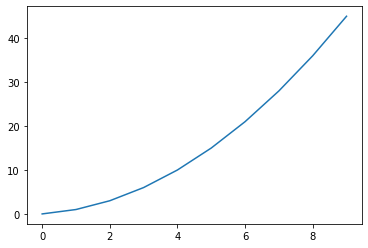

In [130]:
serie_1.plot()

<AxesSubplot:xlabel='c'>

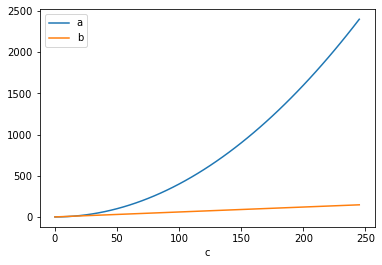

In [134]:
df1= pd.DataFrame({'a': np.arange(50)**2,
                   'b': np.arange(50)*3,
                    'c': np.arange(50)*5})

df1.plot(x='c',y=['a','b'])

## Gráfico de barras

In [135]:
#Tabela da aula passada
soma_qtd_valor

,Quantidade,valor_total,preco_medio
Papel,,,
EMBR3,900,49838.769433,55.376410
ITSA4,900,61451.615028,68.279572
PETR4,1100,43671.836644,39.701670
VVAR3,800,22637.653709,28.297067


<AxesSubplot:xlabel='Papel'>

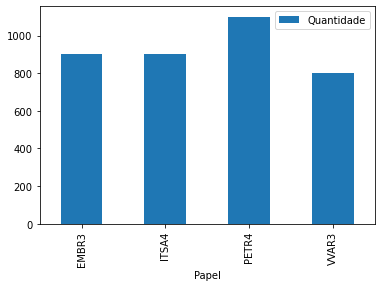

In [137]:
soma_qtd_valor.plot.bar(y = 'Quantidade')

## Gráfico de barras

<AxesSubplot:ylabel='Quantidade'>

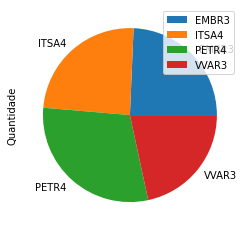

In [140]:
soma_qtd_valor.plot.pie(y = 'Quantidade')

## Scatter

In [143]:
import pandas as pd

file = 'C:/Users/gabriel.pereira/OneDrive - Grupo ITG/Área de Trabalho/Cursos/Python Basico avanç Udemy/Python-para-Engenheiros-e-Cientistas-main/Notebooks/arquivos_auxiliares/datasets_1358_30676_Players.csv'

df2 = pd.read_csv(file)
df2.head()

,Unnamed: 0,Player,height,weight,collage,born,birth_city,birth_state
0,0,Curly Armstrong,180.0,77.0,Indiana University,1918.0,NaN,NaN
1,1,Cliff Barker,188.0,83.0,University of Kentucky,1921.0,Yorktown,Indiana
2,2,Leo Barnhorst,193.0,86.0,University of Notre Dame,1924.0,NaN,NaN
3,3,Ed Bartels,196.0,88.0,North Carolina State University,1925.0,NaN,NaN
4,4,Ralph Beard,178.0,79.0,University of Kentucky,1927.0,Hardinsburg,Kentucky


In [145]:
df2.columns

Index(['Unnamed: 0', 'Player', 'height', 'weight', 'collage', 'born',
       'birth_city', 'birth_state'],
      dtype='object')

<AxesSubplot:xlabel='weight', ylabel='height'>

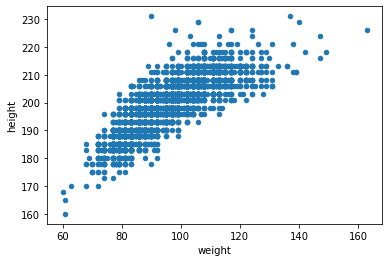

In [149]:
df2.plot.scatter(x='weight',y='height')

## 8.9 Tratando dados de intinerários (Exemplo prático 2)

Dados horários de intinerários, pede-se:
- Encontre e filtre as razões sociais que se repetem duas vezes;
- Encontre quais delas possuem intervalos em menos de uma hora.

https://dados.antt.gov.br/dataset/gerenciamento-de-autorizacoes

Uso do método **.isin** e da função **pd.to_datetime**